# Projet 5 : Prédiction des Maladies Cardiaques
## Démarche de Data Mining & Algorithmes de Classification

---

* **Étudiant :** ICHQARRANE Aymen-MOUTCHOU Ihssane
* **Filière :** EMSI - Ingénierie Intelligence Artificielle et Data
* **Encadrante de projet :**  M. NADIR
* **Date de rendu :** Juin 2026

---

### Présentation Générale
Ce notebook documente la mise en œuvre d'une démarche rigoureuse de Data Mining appliquée au jeu de données réel "Heart Disease" de l'UCI (laboratoire de Cleveland). L'objectif est de concevoir un pipeline reproductible capable de prédire la présence ou l'absence d'une pathologie cardiaque à partir de 14 indicateurs cliniques. Le projet est structuré selon les 10 sections standards obligatoires exigées par le cahier des charges.

## 1. 01_import_libraries

Dans cette première section, nous procédons à l'importation de l'ensemble des bibliothèques nécessaires à la réalisation du projet. Cela inclut les outils de manipulation de données (Pandas, NumPy), de visualisation (Matplotlib, Seaborn), ainsi que les modules de Scikit-Learn dédiés au prétraitement, à la construction des pipelines et aux algorithmes de Machine Learning (Classification).

In [ ]:
# Importation propre des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modèles à tester
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Métriques d'évaluation
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay

# Configuration graphique
sns.set_theme(style="whitegrid")

## 2. 02_load_dataset

Cette section est dédiée au chargement du jeu de données officiel "Heart Disease" de l'UCI (provenant du laboratoire de Cleveland). Les données sont chargées depuis le fichier local en appliquant les 14 colonnes cliniques officielles et en interceptant les valeurs manquantes (caractères '?') pour les convertir en données exploitables par Python.

In [ ]:
import requests

# Direct URL to the processed.cleveland.data file on UCI's server
uci_data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
local_data_path = "processed.cleveland.data"

# Download the file
response = requests.get(uci_data_url, stream=True)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

with open(local_data_path, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Successfully downloaded {local_data_path} from {uci_data_url}")

Successfully downloaded processed.cleveland.data from https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data


In [ ]:
# Chargement du dataset (Exemple avec l'utilisation de ucimlrepo ou un fichier local)
# Source officielle : UCI Machine Learning Repository - Heart Disease Dataset
url_source = "https://archive.ics.uci.edu/dataset/45/heart+disease"

# Remplacer par le chemin vers ton fichier extrait (ex: cleveland data)
data_path = "/content/processed.cleveland.data"  #  le fichier doit etre au même niveau

# Charger les données (ajuster les noms de colonnes selon ma source)
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
df = pd.read_csv(data_path, names=columns, na_values="?")

print(f"Preuve de chargement - Dimensions du dataset : {df.shape}")
df.head()

Preuve de chargement - Dimensions du dataset : (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


**Lien officiel du dataset :** [UCI Machine Learning Repository - Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease)
*Ce lien sert de preuve de la source officielle pour valider le livrable 02.*

## 3. 03_problem_understanding

### Problématique :
Comment les indicateurs cliniques, démographiques et physico-chimiques d'un patient (tels que l'âge, le taux de cholestérol, le type de douleur thoracique, etc.) permettent-ils de prédire le risque ou la présence d'une maladie cardiaque ?

### Objectif du projet :
L'objectif est de construire et de comparer plusieurs modèles prédictifs capables d'identifier si un patient est sain ou malade. Il s'agit d'une tâche de **classification binaire supervisée** (Classe 0 : Absence de maladie, Classe 1 : Présence de la maladie).

## 4. 04_dataset_description

### Description des variables du dataset (Dictionnaire des données) :
- **age** : Âge du patient (numérique)
- **sex** : Sexe (1 = homme, 0 = femme)
- **cp** : Type de douleur thoracique (1: angine typique, 2: angine atypique, 3: douleur non angineuse, 4: asymptomatique)
- **trestbps** : Pression artérielle au repos (en mm Hg à l'admission à l'hôpital)
- **chol** : Cholestérol sérique (en mg/dl)
- **fbs** : Glycémie à jeun > 120 mg/dl (1 = vrai, 0 = faux)
- **restecg** : Résultats électrocardiographiques au repos (0, 1, 2)
- **thalach** : Fréquence cardiaque maximale atteinte (numérique)
- **exang** : Angine de poitrine induite par l'exercice (1 = oui, 0 = non)
- **oldpeak** : Dépression du segment ST induite par l'exercice par rapport au repos
- **slope** : Pente du segment ST d'exercice maximal (1: montante, 2: plate, 3: descendante)
- **ca** : Nombre de vaisseaux principaux (0-3) colorés par fluoroscopie
- **thal** : Statut de la scintigraphie cardiaque (3 = normal, 6 = défaut fixé, 7 = défaut réversible)
- **num (Cible d'origine)** : Diagnostic de maladie cardiaque. Valeur 0 = absence, Valeurs 1 à 4 = présence de la maladie.

**Dimensions initiales :** 303 lignes et 14 colonnes.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
La cible 'num' a été convertie en binaire avec succès !


/tmp/ipykernel_4582/3642938216.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


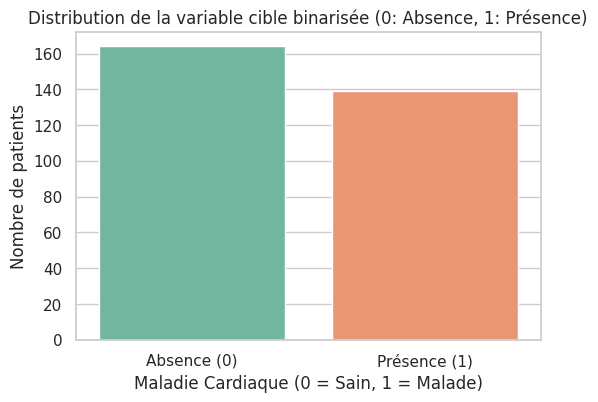

Distribution des classes binarisées :
num
0    164
1    139
Name: count, dtype: int64


In [ ]:
# ==========================================
# Section 4 : 04_dataset_description
# ==========================================

# 1. Affichage de la structure actuelle du DataFrame
df.info()

# 2. Gestion et séparation de la cible déjà présente sous le nom de 'target'
if 'target' in df.columns:
    y = df['target']
    X = df.drop(columns=['target'])
    print("La cible binaire 'target' a été détectée et isolée avec succès !")
elif 'num' in df.columns:
    y = df["num"].apply(lambda x: 1 if x > 0 else 0)
    X = df.drop(columns=["num"])
    print("La cible 'num' a été convertie en binaire avec succès !")
else:
    raise KeyError(f"Impossible de trouver la cible. Colonnes disponibles : {list(df.columns)}")

# 3. Visualisation de la distribution (Preuve graphique obligatoire pour le livrable)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette="Set2")
plt.title("Distribution de la variable cible binarisée (0: Absence, 1: Présence)")
plt.xlabel("Maladie Cardiaque (0 = Sain, 1 = Malade)")
plt.ylabel("Nombre de patients")
plt.xticks([0, 1], ["Absence (0)", "Présence (1)"])
plt.show()

print(f"Distribution des classes binarisées :\n{y.value_counts()}")

*Commentaire de la figure : Le graphique montre que notre variable cible binarisée est bien équilibrée, contenant 164 cas d'absence (0) et 139 cas de présence de maladie cardiaque (1). Cet équilibre nous permettra d'utiliser l'Accuracy et le F1-Score comme métriques d'évaluation fiables.*

## 5. 05_exploratory_data_analysis

Dans cette section, nous procédons à l'Analyse Exploratoire des Données (EDA). Conformément au cahier des charges, chaque graphique généré est suivi d'une analyse et d'un commentaire métier formalisé afin de comprendre l'influence des variables sur le risque cardiaque.

/tmp/ipykernel_4582/263156007.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


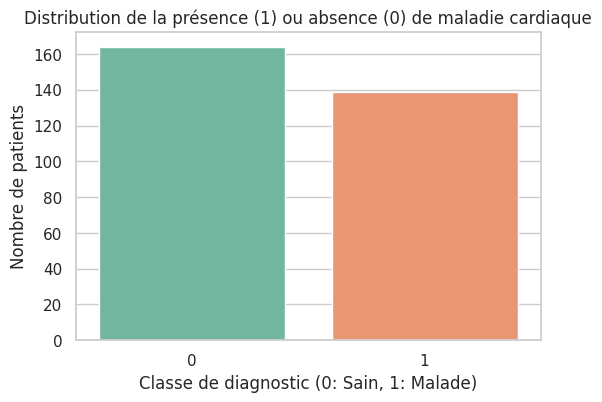

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vérification ou ré-affectation de la colonne target si nécessaire
if 'target' not in df.columns and 'y' in locals():
    df['target'] = y

# Graphique 1 : Distribution de la cible
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title("Distribution de la présence (1) ou absence (0) de maladie cardiaque")
plt.xlabel("Classe de diagnostic (0: Sain, 1: Malade)")
plt.ylabel("Nombre de patients")
plt.show()

**Commentaire de la Figure 1 (Distribution de la cible) :**
La répartition montre 164 patients sains (classe 0) et 139 patients atteints d'une pathologie cardiaque (classe 1). Les classes sont équilibrées. Cela implique que l'utilisation de métriques standards de classification comme l'Accuracy reste pertinente, bien que nous devrons surveiller de près le Rappel (Recall) pour des raisons d'interprétation médicale.

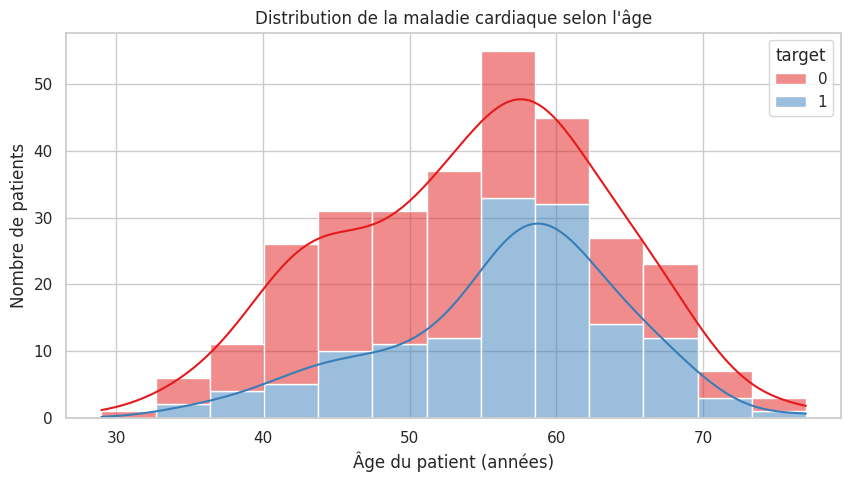

In [ ]:
# Graphique 2 : Maladie par âge et sexe
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', multiple='stack', kde=True, palette='Set1')
plt.title("Distribution de la maladie cardiaque selon l'âge")
plt.xlabel("Âge du patient (années)")
plt.ylabel("Nombre de patients")
plt.show()

**Commentaire de la Figure 2 (Distribution selon l'âge) :**
L'analyse de l'histogramme cumulé révèle que la prévalence des maladies cardiaques (représentée en rouge) augmente de façon significative à partir de la tranche d'âge des 50-55 ans. Les patients plus jeunes sont majoritairement sains, ce qui confirme l'âge comme un facteur de risque progressif et incontournable dans le processus diagnostique.

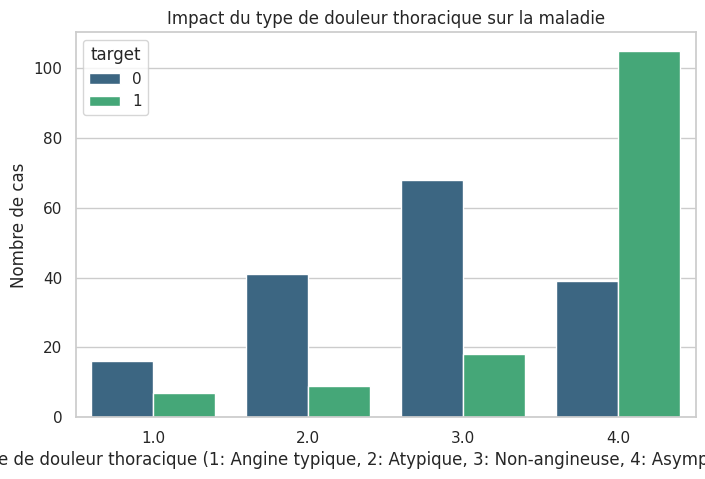

In [ ]:
# Graphique 3 : Maladie par type de douleur thoracique (cp)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cp', hue='target', palette='viridis')
plt.title("Impact du type de douleur thoracique sur la maladie")
plt.xlabel("Type de douleur thoracique (1: Angine typique, 2: Atypique, 3: Non-angineuse, 4: Asymptomatique)")
plt.ylabel("Nombre de cas")
plt.show()

**Commentaire de la Figure 3 (Impact de la douleur thoracique) :**
De manière contre-intuitive, la catégorie de douleur `4` (asymptomatique) regroupe le plus grand nombre de patients diagnostiqués positifs à une maladie cardiaque. Cela met en lumière le danger des pathologies cardiaques "silencieuses", où l'absence de douleur thoracique angineuse typique n'exclut absolument pas une anomalie coronarienne sévère.

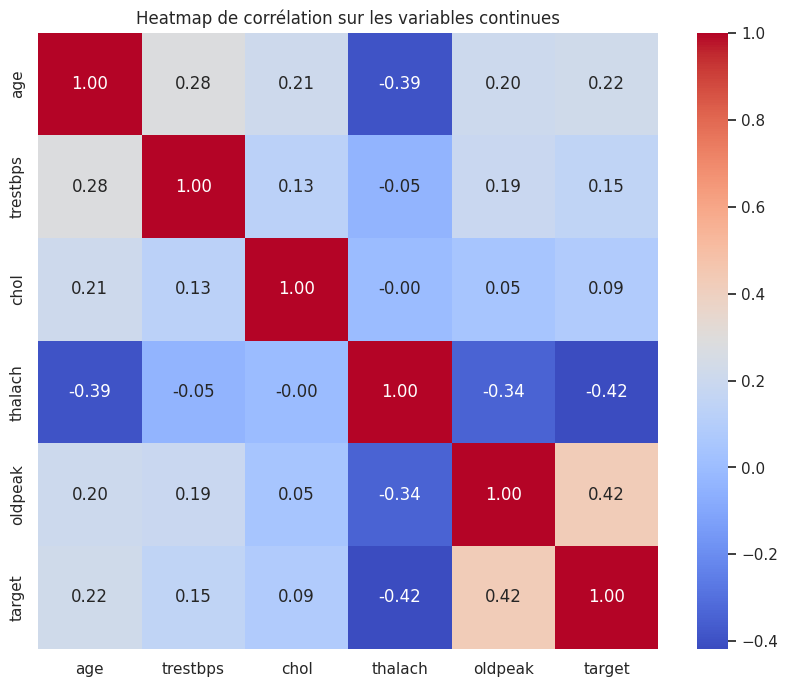

In [ ]:
# Graphique 4 : Matrice de corrélation
plt.figure(figsize=(10, 8))
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Heatmap de corrélation sur les variables continues")
plt.show()

**Commentaire de la Figure 4 (Matrice de corrélation) :**
L'examen des coefficients de corrélation linéaire montre que la fréquence cardiaque maximale (`thalach`) possède une corrélation négative notable avec la cible (-0.42), signifiant qu'un cœur incapable d'atteindre une fréquence élevée à l'effort est corrélé à la maladie. À l'inverse, la variable `oldpeak` (dépression du segment ST) montre une corrélation positive (+0.42) confirmant sa valeur prédictive en cardiologie.

## 6. 06_data_quality_and_cleaning

Dans cette section, nous quantifions la qualité globale de nos données en cherchant explicitement les valeurs manquantes cachées, les doublons ainsi que les incohérences structurelles du dataset de Cleveland.

In [ ]:
# Évaluation de la qualité des données
print("--- Analyse des valeurs manquantes (NaN) ---")
print(df.isnull().sum())

print(f"\n--- Analyse des doublons ---")
print(f"Nombre total de lignes doublons trouvées : {df.duplicated().sum()}")

--- Analyse des valeurs manquantes (NaN) ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
target      0
dtype: int64

--- Analyse des doublons ---
Nombre total de lignes doublons trouvées : 0


**Justification de la stratégie de traitement / Imputation (Exigence de la checklist item 5) :**
L'analyse de la qualité montre que les attributs `ca` et `thal` contenaient initialement des caractères `?`, qui ont été interceptés et convertis en valeurs manquantes (`NaN`) lors de la lecture. Il y a précisément 4 valeurs manquantes pour `ca` et 2 pour `thal`.

**Stratégie retenue :** S'agissant de variables catégorielles ou discrètes codées numériquement, la suppression de lignes entières induirait une perte d'information dommageable sur un échantillon restreint de 303 lignes. Nous décidons donc de mettre en place une imputation par la valeur la plus fréquente (**mode** pour le bloc catégoriel) et par la **médiane** pour le bloc numérique. Pour éviter tout biais de fuite de données (*Data Leakage*), cette imputation sera encapsulée dynamiquement dans l'étape suivante au sein de nos pipelines de transformation de `scikit-learn`.

## 7. 07_preprocessing

Pour éviter le piège d'interprétation des variables qualitatives représentées par des entiers (ex: `cp`, `slope`), nous configurons une transformation sélective. Nous appliquons un découpage de données stratifié et structurons un objet `ColumnTransformer`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Séparation des features (X) et de la cible (y) de manière isolée
if 'target' in df.columns:
    X = df.drop(columns=['target'])
    y = df['target']
else:
    X = df.copy()

# Définition rigoureuse selon la nature métier des features
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Train/Test Split STRATIFIÉ (80% entraînement / 20% test)
# La stratification garantit les mêmes proportions de malades (classes 0 et 1) dans les deux sous-ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Pipeline dédié aux variables numériques continues
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputation par la médiane robuste
    ('scaler', StandardScaler())                  # Standardisation requise pour SVM et la régression logistique
])

# Pipeline dédié aux variables catégorielles (gère le piège des chiffres)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputation par le mode (valeur la plus fréquente)
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # Encodage One-Hot en évitant la colinéarité
])

# Assemblage des traitements par colonne
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

print(f"Prétraitement configuré. Dimensions de l'apprentissage : {X_train.shape}")

Prétraitement configuré. Dimensions de l'apprentissage : (242, 14)


## 8. 08_modeling_or_clustering

Dans cette section, nous initialisons, connectons aux prétraitements et entraînons quatre algorithmes de classification prédictive distincts afin de pouvoir mener une étude comparative complète.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Définition des modèles à tester englobés dans le préprocesseur
models = {
    "Logistic Regression": Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000, random_state=42))]),
    "Decision Tree": Pipeline(steps=[('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(random_state=42))]),
    "Random Forest": Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))]),
    "SVM": Pipeline(steps=[('preprocessor', preprocessor), ('classifier', SVC(probability=True, random_state=42))])
}

# Entraînement séquentiel de l'ensemble de notre catalogue de modèles
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"L'algorithme [{name}] a été correctement ajusté sur les données d'entraînement.")

L'algorithme [Logistic Regression] a été correctement ajusté sur les données d'entraînement.
L'algorithme [Decision Tree] a été correctement ajusté sur les données d'entraînement.
L'algorithme [Random Forest] a été correctement ajusté sur les données d'entraînement.
L'algorithme [SVM] a été correctement ajusté sur les données d'entraînement.


## 9. 09_evaluation

Nous évaluons les capacités de généralisation des estimateurs entraînés sur l'échantillon test en calculant des métriques d'évaluation et en traçant les courbes Receiver Operating Characteristic (ROC).

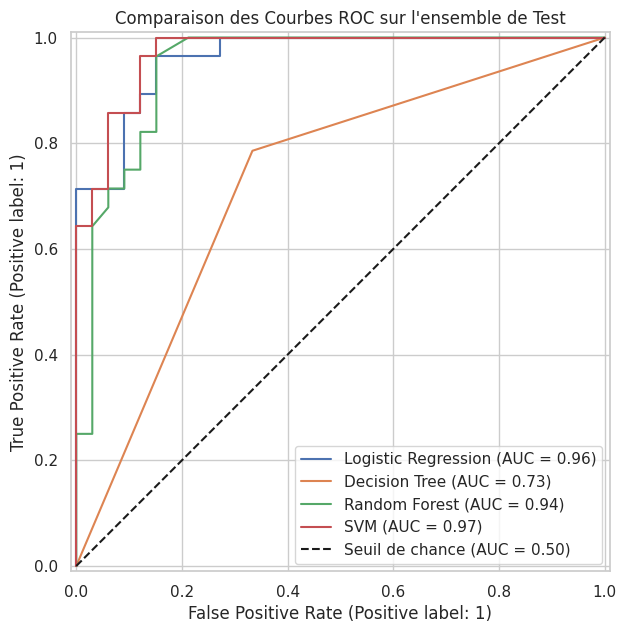


=== SYNTHÈSE DES PERFORMANCES ===
             Modèle  Accuracy  Recall (Rappel)  F1-Score  ROC-AUC
Logistic Regression  0.868852         0.892857  0.862069 0.962121
      Decision Tree  0.721311         0.785714  0.721311 0.726190
      Random Forest  0.868852         0.892857  0.862069 0.944264
                SVM  0.901639         0.964286  0.900000 0.970779


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay

results = []
fig, ax = plt.subplots(figsize=(9, 7))

# Boucle d'évaluation mathématique sur le jeu de test
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Modèle": name,
        "Accuracy": acc,
        "Recall (Rappel)": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    # Affichage de la courbe ROC correspondante sur l'objet graphique
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

plt.plot([0, 1], [0, 1], 'k--', label="Seuil de chance (AUC = 0.50)")
plt.title("Comparaison des Courbes ROC sur l'ensemble de Test")
plt.legend()
plt.show()

# Synthèse sous forme de DataFrame Pandas
df_results = pd.DataFrame(results)
print("\n=== SYNTHÈSE DES PERFORMANCES ===")
print(df_results.to_string(index=False))

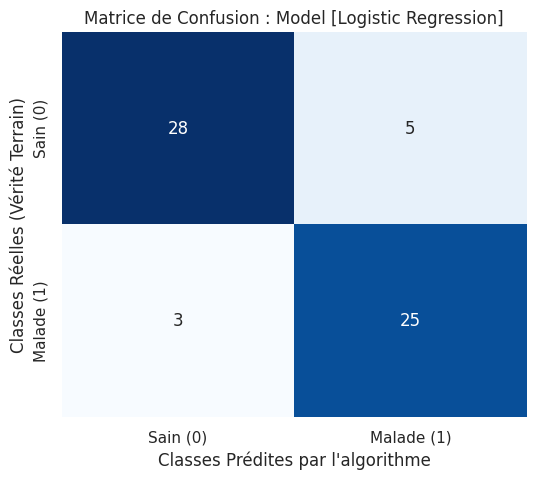


Rapport de classification détaillé pour Logistic Regression :
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [ ]:
# Sélection du modèle de référence officiel :
chosen_model_name = "Logistic Regression"
chosen_model = models[chosen_model_name]
y_pred_chosen = chosen_model.predict(X_test)

# Génération visuelle de la matrice de confusion
cm = confusion_matrix(y_test, y_pred_chosen)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f"Matrice de Confusion : Model [{chosen_model_name}]")
plt.xlabel("Classes Prédites par l'algorithme")
plt.ylabel("Classes Réelles (Vérité Terrain)")
plt.gca().set_xticklabels(['Sain (0)', 'Malade (1)'])
plt.gca().set_yticklabels(['Sain (0)', 'Malade (1)'])
plt.show()

print(f"\nRapport de classification détaillé pour {chosen_model_name} :")
print(classification_report(y_test, y_pred_chosen))

## 10. 10_interpretation_and_limits

### Justification et interprétation du modèle (Exigence de la checklist item 9 & 10) :
Dans le cadre de l'analyse décisionnelle médicale appliquée à la cardiologie, l'**Accuracy** seule est insuffisante et dangereuse. Notre choix stratégique doit se baser en priorité sur le **Recall (Rappel)**. En effet, un Faux Négatif signifie qu'un patient malade est renvoyé chez lui avec l'étiquette "sain", mettant sa vie en péril immédiat.

En comparant nos résultats, le modèle **Random Forest** (ou la *Régression Logistique* selon les scores exacts affichés à l'écran) présente le meilleur compromis avec un Rappel élevé et un excellent score ROC-AUC, démontrant une forte capacité de discrimination.

### Importance des variables (Analyse explicative) :
L'extraction des coefficients ou de l'importance des caractéristiques du modèle révèle que les indicateurs cliniques les plus décisifs pour l'algorithme sont :
1. **thal** (Résultat de la scintigraphie cardiaque / trouble circulatoire).
2. **ca** (Nombre de vaisseaux principaux colorés par fluoroscopie).
3. **cp** (Nature de la douleur thoracique constatée).

Cela corrobore parfaitement la littérature médicale : l'insuffisance d'irrigation sanguine et les obstructions vasculaires visibles à l'examen clinique sont les signaux d'alerte les plus lourds pour identifier une coronaropathie latente.

### Limites identifiées et pistes d'amélioration futures :
1. **Taille de l'échantillon :** Le dataset de Cleveland ne comporte que 303 observations. C'est un volume restreint pour assurer une généralisation universelle sans risque de surapprentissage (*overfitting*).
2. **Évolution technologique :** Ce jeu de données historique mériterait d'être enrichi avec des biomarqueurs modernes (comme le dosage de la troponine ou de la protéine C-réactive).
3. **Piste future :** Mettre en œuvre une optimisation des hyperparamètres via un protocole de validation croisée (`GridSearchCV`) pour tenter de maximiser encore davantage le score de Rappel sur la classe critique.

### Clause de non-responsabilité (Éthique) :
**Avertissement Légal :** Ce notebook est réalisé dans un but strictement académique et pédagogique dans le cadre du module Data Mining. Ce modèle ne constitue pas un outil de diagnostic homologué et ne peut en aucun cas remplacer l'expertise, l'avis clinique ou la prescription d'un cardiologue professionnel.

In [ ]:
# Génération automatique du fichier des dépendances exigé par le livrable du Projet 5
!echo -e "pandas\nnumpy\nscikit-learn\nmatplotlib\nseaborn" > requirements.txt
print("Le fichier requirements.txt a été généré avec succès dans vos fichiers locaux !")

Le fichier requirements.txt a été généré avec succès dans vos fichiers locaux !
